# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- R= En el dataset "users", hay un total de 469 datos faltantes en la columna "city", lo cual representa un 11.73%, y la columna "churn_date" hay un total de 3,534 datos faltantes, lo que representa un 88.35% de datos nulos para esa columna.
- En el dataset "usage", hay un total de 50 datos nulos para la columna "date", lo que representa <1% de datos faltantes. En la columna "duration" y "lenght", se tiene un total de 22,076 y 17,896 datos faltantes respectivamente, lo cual representa el 55.19% y 44.74% de datos nulos según corresponde.

- Indica qué harías: ¿imputar, eliminar, ignorar?
- Para el primer dataset "users", se debería investigar la columna de "city" para imputar o dejar como nulos. La columna "churn_date" se puede ignorar debido a la naturaleza de los datos, ya que hace referencia a los suscriptores que se han dado de baja de algún plan, aunque de ser necesario, se puede analizar esta columna con fines específicos.
- Para el segundo dataset "usage", la columna "date" podría imputarse ya que son muy pocos datos nulos. Para las columnas "duration" y "lenght", el porcentaje de nulos es alto debido a que son datos complementarios, es decir, los datos que se encuentran en una categoría NO pueden estar en la otra, y ambas columnas completan el 99.93% de los datos. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` realmente muestra datos que hacen referencia al # de ID de cada cliente, no es relevante.
- La columna `age`, por otra parte, muestra una desviación estándar de 123.23 y un min de -999, lo cual evidencia la existencia de valores inválidos

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].describe())
    print(users[col].value_counts())
    print(users[col].value_counts(normalize=True))


count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: city, dtype: float64
count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object
Basico     2595
Premium    1405
Name: plan, dtype: int64
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


- La columna `city` presenta un total de 3,531 datos no nulos, siendo el más frecuente la ciudad de Bogotá con un 22.88% del total de los datos, seguido de CDMX y Medellín con in 20.67% y 17.45% respectivamente. Las ciudades con "?" solo representan el 2.72% del total de los datos.
- La columna `plan` presenta un total de 4,000 datos, lo cual nos indica que en la columna `city` existen 469 datos faltantes (lo cual ya se había visto en la sección 2.1). También existe una diferencia clara entre el porcentaje de usuarios que prefieren el plan "básico" a comparación del "premium", con un total del 64.88% de los usuarios.

In [15]:
# explorar columna categórica de usage
print(usage['type'].describe())
print(usage['type'].value_counts())
print(usage['type'].value_counts(normalize=True))

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object
text    22092
call    17908
Name: type, dtype: int64
text    0.5523
call    0.4477
Name: type, dtype: float64


- La columna `type` no presenta datos inexistentes. Los porcentajes del detalle de uso son similares, siendo "text" un 55.23% y "call" un 44.77%.


✍️ **Comentario**: 
- Se identificaron valores inválidos en la columna age, donde el valor mínimo es -999. Dado que una edad negativa no es posible, este valor parece haber sido utilizado como un sentinel para representar datos faltantes o desconocidos. Mi recomendación sería reemplazar los valores -999 por valores ausentes (NaN) para evitar que afecten los análisis estadísticos. Posteriormente, estos valores pueden imputarse utilizando una medida adecuada (como la mediana de edad según algún grupo relevante) o eliminarse si representan una proporción muy pequeña del conjunto de datos.
- También se observó que la columna city contiene registros con el valor "?", que probablemente representan ciudades desconocidas o no registradas. Mi recomendación sería sustituir los valores "?" por una categoría como "Unknown" o convertirlos en valores ausentes (NaN) para tratarlos de manera consistente durante la limpieza de datos.
- Las columnas id y user_id contienen valores numéricos, pero corresponden a identificadores únicos y no representan información que requiera corrección o imputación.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors= 'coerce')
users['reg_date'].dtype

dtype('<M8[ns]')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors= 'coerce')
usage['date'].dtype

dtype('<M8[ns]')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se registran los años 2022, 2023, 2024 y 2026, siendo este último una fecha imposible ya que solo hay datos registrados hasta el año 2024. 

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, todos los registros pertenecen al año 2024. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: para el dataset de "users" existen datos con fechas de 2022 a 2024, más 40 datos con año 2026 (una fecha imposible ya que solo hay datos registrados hasta 2024), lo cual es un porcentaje pequeño pero se recomienda marcarlas como nulas para no eliminar esa información. En el dataset "usage", solo se cuentan con registros de 2024, así que únicamente se pueden hacer comparativas de este año.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, np.nan)
users['age']= users['age'].fillna(users['age'].median())

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > '2024-12-31', 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage["type"]).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los valores faltantes en `duration` y `length` dependen directamente de la variable type. Los registros de tipo call presentan información de duración pero no de longitud, mientras que los registros de tipo text presentan longitud pero no duración. Por lo tanto, los valores ausentes no son aleatorios, sino que están explicados por una variable observada (type), siendo consistentes con un mecanismo MAR (Missing At Random). No se recomienda imputar estos valores, ya que representan características inherentes al tipo de uso registrado.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text' : 'sum',
    'is_call' : 'sum',
    'duration' : 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg= usage_agg.rename(columns={'is_text':'cant_mensajes', 'is_call':'cant_llamadas', 'duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
usage_agg.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,23.317054
std,1154.898108,2.358416,2.144238,18.168095
min,10000.000000,0.000000,0.000000,0.000000
25%,10999.500000,4.000000,3.000000,11.120000
50%,12000.000000,5.000000,4.000000,19.780000
75%,12999.500000,7.000000,6.000000,31.415000
max,13999.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

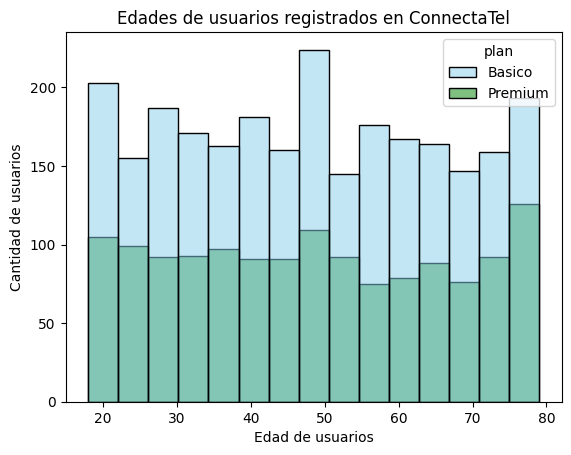

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=users, x='age', bins= 15, hue='plan', palette=['skyblue', 'green'])
plt.xlabel('Edad de usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Edades de usuarios registrados en ConnectaTel')
plt.show()

💡Insights: Es evidente que hay una mayor cantidad de usuarios que contratan el paquete "básico" sobre el "premium". Las edades no presentan una distribución sesgada en ninguno de los dos casos; los datos se mantienen prácticamente iguales tanto para la contratación del tipo de plan, como para la diferencia de edades de los clientes.

Text(0.5, 1.0, 'Cantidad de mensajes enviados por usuarios de ConnectaTel')

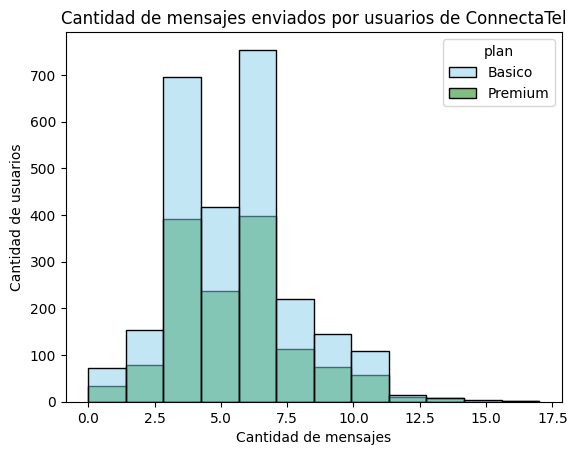

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=12, hue='plan', palette=['skyblue', 'green'])
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de mensajes enviados por usuarios de ConnectaTel')

💡Insights: Para este caso, de igual manera se aprecia una mayor cantidad de clientes que contratan el plan básico que el premium, pero aquí si se observa un ligero sesgo hacia la derecha, lo que significa que la mayoría de usuarios envía pocos mensajes (<7 aproximadamente), tanto para el plan básico como para el premium.

Text(0.5, 1.0, 'Cantidad de llamadas realizadas por usuarios de ConnectaTel')

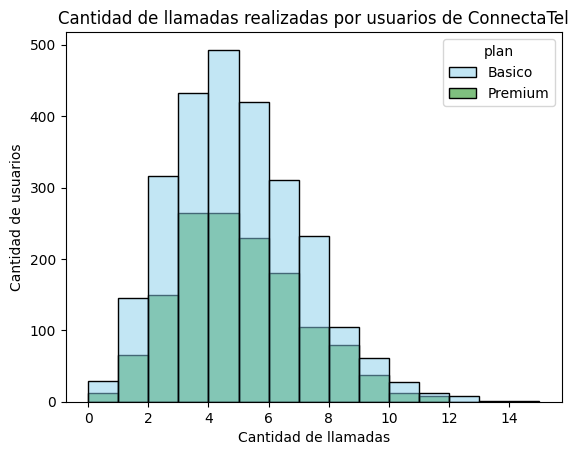

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=15, hue='plan', palette=['skyblue', 'green'])
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de llamadas realizadas por usuarios de ConnectaTel')

💡Insights: Para este caso, de igual manera se aprecia una mayor cantidad de clientes que contratan el plan básico que el premium, y aquí también se observa un ligero sesgo hacia la derecha, lo que significa que la mayoría de usuarios realiza pocas llamadas (<8 aproximadamente), tanto para el plan básico como para el plan premium.

Text(0.5, 1.0, 'Cantidad de minutos de llamadas realizadas por usuarios de ConnectaTel')

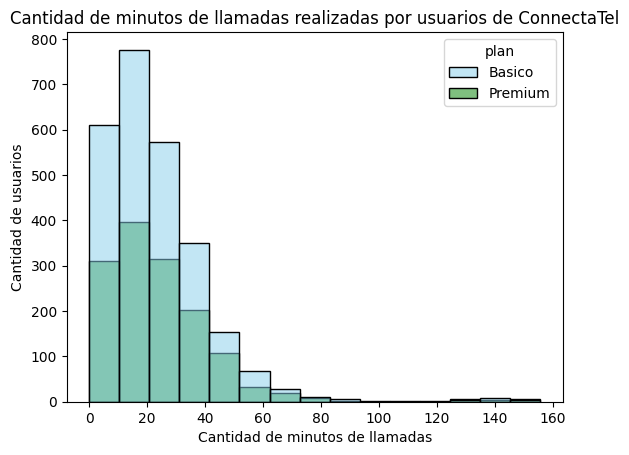

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=15, hue='plan', palette=['skyblue', 'green'])
plt.xlabel('Cantidad de minutos de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de minutos de llamadas realizadas por usuarios de ConnectaTel')

💡Insights: Para este caso, de igual manera se aprecia una mayor cantidad de clientes que contratan el plan básico que el premium, y aquí se observa claramente un sesgo hacia la derecha, lo que significa que la mayoría de usuarios utiliza pocos minutos de llamadas (aproximadamente <50 min).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

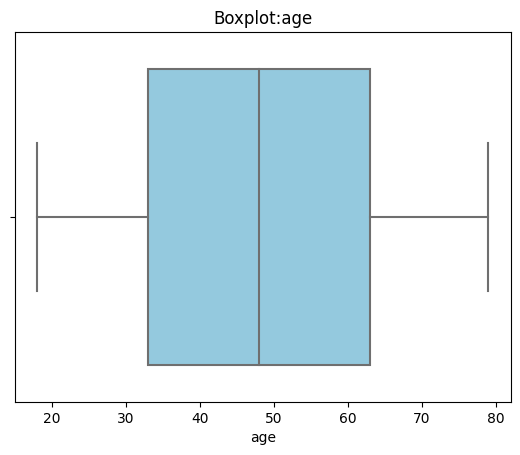

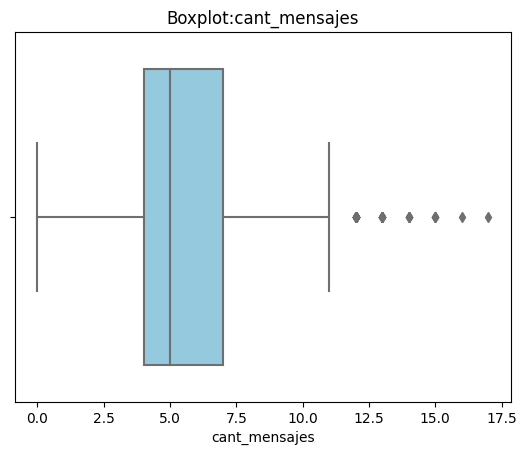

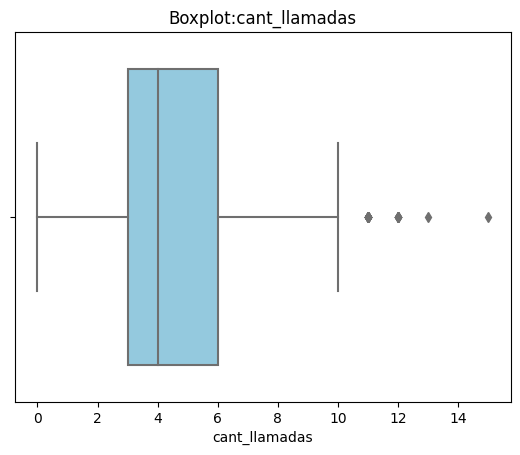

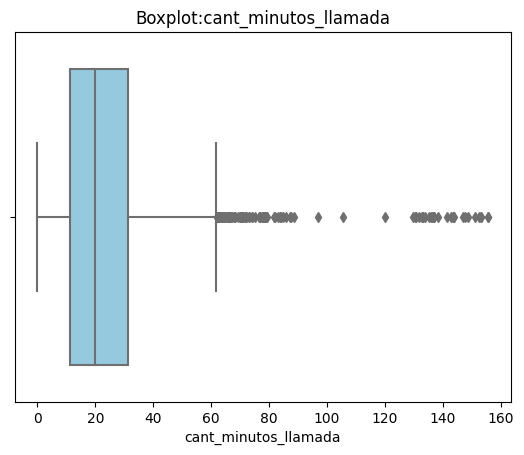

In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure()
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot:{col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers.
- cant_mensajes: presenta valores atípicos leves.
- cant_llamadas: presenta valores atípicos leves.
- cant_minutos_llamada: presenta valores atípicos extremos.

In [41]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1= user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR= Q3 - Q1
    Lim_inferior= Q1 - 1.5 * IQR
    Lim_superior= Q3 + 1.5 * IQR
    print ('Columna:', col)
    print ('Primer cuartil:', Q1)
    print ('Tercer cuartil:', Q3)
    print ('IQR:', IQR)
    print ('Límite inferior:', Lim_inferior)
    print ('Límite superior:', Lim_superior)



Columna: cant_mensajes
Primer cuartil: 4.0
Tercer cuartil: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5
Columna: cant_llamadas
Primer cuartil: 3.0
Tercer cuartil: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5
Columna: cant_minutos_llamada
Primer cuartil: 11.12
Tercer cuartil: 31.415
IQR: 20.295
Límite inferior: -19.322500000000005
Límite superior: 61.8575


In [40]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes:** se mantienen los outliers porque son valores atípicos leves, además de que el máximo registrado es 17 y la cantidad de mensajes incluidos en el plan básico es de 100, y en el premium es de 600.
- **cant_llamadas:** se mantienen los outliers porque son valores atípicos leves, no hay mucha diferencia entre el límite superior (10.5) y el máximo registrado (15).
- **cant_minutos_llamada:** aquí deben eliminarse los outliers que sean mayores a 100 únicamente del plan básico, ya que 100 es el límite de minutos de ese paquete. En el plan premium, el límite de minutos es de 600, por lo que no serían datos imposibles, y el máximo registrado es 155.69. Se usa el siguiente código: (user_profile['plan'] == 'Basico') & (user_profile['cant_minutos_llamada'] >100)

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [50]:
# Crear columna grupo_uso
def grupo_uso(row):
    mensajes=row['cant_mensajes']
    llamadas=row['cant_llamadas']

    if mensajes < 5 and llamadas <5:
        return "Bajo uso"
    elif mensajes <10 and llamadas <10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile['grupo_uso']=user_profile.apply(grupo_uso, axis=1)

In [51]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [58]:
# Crear columna grupo_edad
def grupo_edad(row):
    edad=row["age"]
    
    if edad <30:
        return "Joven"
    elif edad <60:
        return "Adulto"
    else:
        return "Adulto mayor"
user_profile['grupo_edad']=user_profile.apply(grupo_edad, axis=1)

In [59]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

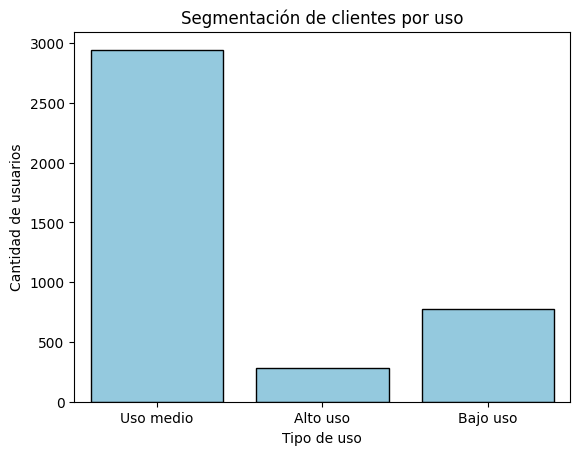

In [63]:
# Visualización de los segmentos por uso
sns.countplot(user_profile["grupo_uso"], color='skyblue', edgecolor='black')
plt.xlabel('Tipo de uso')
plt.ylabel('Cantidad de usuarios')
plt.title('Segmentación de clientes por uso')

plt.show()

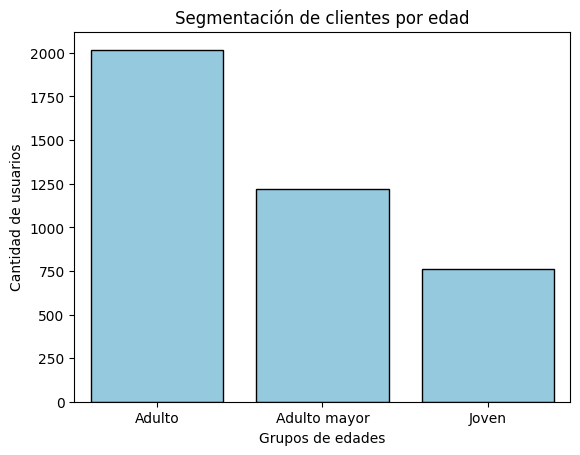

In [64]:
# Visualización de los segmentos por edad
sns.countplot(user_profile["grupo_edad"], color='skyblue', edgecolor='black')
plt.xlabel('Grupos de edades')
plt.ylabel('Cantidad de usuarios')
plt.title('Segmentación de clientes por edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Durante la etapa de exploración se identificaron valores faltantes y registros inconsistentes en ambos conjuntos de datos.

- En el dataset users, la columna 'city' presentó 469 valores faltantes, equivalentes al 11.73% de los registros. Asimismo, la columna 'churn_date' registró 3,534 valores nulos (88.35%); sin embargo, estos valores son esperados debido a que únicamente los clientes que cancelan su servicio cuentan con una fecha de baja registrada.

- En el dataset usage, la columna 'date' presentó únicamente 50 valores faltantes (menos del 1% de los registros), por lo que su impacto en el análisis es mínimo. Por otro lado, las columnas 'duration' y 'length' mostraron 22,076 (55.19%) y 17,896 (44.74%) valores nulos, respectivamente.

- Además de los valores faltantes, se identificaron otros problemas de calidad:

- La columna 'age' contenía valores inválidos representados por el sentinel -999, equivalentes a edades imposibles. Estos registros fueron reemplazados por la mediana de la variable para evitar sesgos en el análisis.
- La columna 'city' contenía registros con el valor "?", los cuales fueron tratados como datos faltantes (NaN) para su correcta gestión.
- La columna 'reg_date' incluía registros correspondientes al año 2026, una fecha fuera del rango temporal del proyecto, ya que la información disponible abarca únicamente hasta 2024. Estos registros fueron reemplazados por valores nulos.

- Respecto a las columnas 'duration' y 'length', se verificó que los valores faltantes no corresponden a errores de captura. El análisis mostró que estos dependen de la variable 'type': los registros de tipo llamada contienen información de duración pero no de longitud de mensaje, mientras que los registros de tipo mensaje contienen longitud pero no duración. Por lo tanto, estos valores ausentes son consistentes con la naturaleza de los datos y no requieren imputación.

🔍 **Segmentos por Edad**
- La segmentación por edad permitió identificar tres grupos principales:

1.- Jóvenes (<30 años): representan la minoría la base de clientes, siendo aproximadamente la mitad del grupo con mayor cantidad de clientes (adultos).
2.- Adultos (30-59 años): constituyen el segmento más amplio de la cartera de clientes.
3.- Adultos mayores (60+ años): representan el 2° lugar de la mayor proporción de usuarios.

Sin embargo, en la contratación del plan, no hay un sesgo que infiera que algún grupo de edad prefiere el plan "básico" o "premium", ya que los datos se mantienen prácticamente iguales.


📊 **Segmentos por Nivel de Uso**
- Se identificaron tres niveles de uso:

1.- Bajo uso: usuarios con menos de 5 llamadas y menos de 5 mensajes.
2.- Uso medio: usuarios con actividad moderada tanto en llamadas como en mensajes (<10).
3.- Alto uso: usuarios que superan los niveles promedio de llamadas y mensajes.

Los histogramas muestran una clara concentración de usuarios en niveles bajos de consumo. La mayoría realiza pocas llamadas, envía pocos mensajes y utiliza menos de 50 minutos de llamadas en el periodo analizado.

➡️ Esto sugiere que los usuarios de alto uso, especialmente aquellos que utilizan más minutos de llamada y mantienen una actividad constante, representan el segmento con mayor potencial de valor para la empresa. Estos clientes tienen una mayor probabilidad de consumir beneficios adicionales, contratar planes superiores o adquirir servicios complementarios.

Asimismo, los usuarios del plan Premium constituyen un grupo estratégico debido a su mayor capacidad de consumo y potencial de generación de ingresos recurrentes.

**El análisis de outliers mostró que:**

- La variable age no presenta valores atípicos relevantes.
- Las variables cant_mensajes y cant_llamadas presentan únicamente outliers leves, por lo que fueron conservados al representar comportamientos reales de algunos usuarios.
- La variable cant_minutos_llamada presentó outliers más pronunciados. Se identificaron registros que excedían los límites permitidos del plan Básico, por lo que fueron revisados y se sugiere su depuración para que no interfieran en las estadísticas.

Estos comportamientos extremos pueden representar clientes con necesidades de comunicación más intensivas y constituyen una oportunidad para diseñar ofertas especializadas.

💡 **Recomendaciones**
- Diseñar planes intermedios dirigidos a usuarios de uso medio, ofreciendo beneficios adicionales sin llegar al costo completo del plan Premium.
- Crear promociones específicas para usuarios de alto consumo, incentivando la permanencia y reduciendo el riesgo de migración hacia la competencia.
- Implementar campañas de actualización de plan para clientes del plan Básico que se acerquen con frecuencia a los límites de uso incluidos.
- Mantener procesos de validación automática de datos para evitar la captura de edades inválidas, fechas fuera de rango y valores sentinela.
- Analizar con mayor profundidad los usuarios de alto consumo, ya que representan una oportunidad para desarrollar productos premium o paquetes especializados.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`